# Machine Learning Prediction of Superconducting Critical Temperature

- Eli Andrae

This notebook reframes an earlier class project into a cleaner, more reproducible, and more interpretable machine learning analysis.

### Research question
Can compositional descriptors derived from elemental properties predict the superconducting critical temperature of a material, and do those descriptors reveal meaningful structure in feature space?

### Why this matters
Predicting superconducting critical temperature remains difficult because candidate compounds span a large and complex compositional landscape. Machine learning can serve as a screening tool by identifying broad patterns, grouping related materials, and estimating which properties are most informative for superconducting behavior.

### Workflow
1. Load and inspect the dataset  
2. Preprocess and standardize features  
3. Explore structure with PCA  
4. Identify groups with K-Means  
5. Predict critical temperature with Random Forest regression  
6. Evaluate performance and inspect feature importances  
7. Summarize limitations and future directions

## Dataset

This analysis uses the **UCI Superconductivity Dataset**, which contains approximately 21,000 superconducting compounds. Each row corresponds to a material, with numerical descriptors summarizing composition-based elemental statistics such as:

- atomic mass
- atomic radius
- valence
- thermal conductivity
- electron affinity
- density

The target variable is:

- **`critical_temp`**: the superconducting critical temperature in Kelvin

> Place the dataset CSV at `../data/superconductor.csv` before running the notebook.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from src.data import load_dataset, train_test_data, scale_train_test, split_features_target
from src.models import (
    fit_pca,
    fit_kmeans,
    fit_evaluate_random_forest,
    cross_validate_random_forest,
    feature_importance_table,
)
from src.plots import (
    plot_target_distribution,
    plot_pca_variance,
    plot_clusters,
    plot_pc_vs_target,
    plot_predictions,
    plot_feature_importance,
)
from src.utils import display_metrics

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
csv_path = Path("../data/superconductor.csv")
data = load_dataset(csv_path)

print(f"Dataset shape: {data.shape}")
print(f"Number of features including target: {data.shape[1]}")
data.head()

Dataset shape: (21263, 82)
Number of features including target: 82


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## Initial Data Review

The dataset is entirely numerical, which makes it a natural candidate for a tree-based regressor and for dimensionality reduction methods like PCA.

In [5]:
X_train, X_test, y_train, y_test = train_test_data(data, target_col="critical_temp", test_size=0.2)
X_train_scaled, X_test_scaled, scaler = scale_train_test(X_train, X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17010, 81)
X_test : (4253, 81)
y_train: (17010,)
y_test : (4253,)


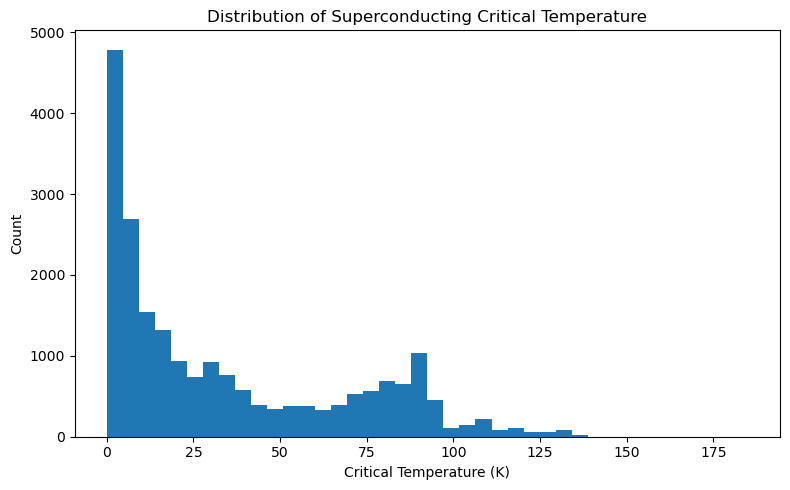

In [6]:
plot_target_distribution(data["critical_temp"])

The target distribution is typically right-skewed, with many lower-temperature superconductors and a smaller number of higher-Tc materials. That matters because a model can achieve strong average performance while still being less precise in the highest-value or sparsest regions of the target space.

## Exploratory Structure with PCA

PCA is used here as a visualization tool rather than a predictive model. The aim is to determine whether the 81-dimensional feature space contains broad lower-dimensional structure that corresponds to different material regimes.

In [7]:
X_train_pca, X_test_pca, pca, loadings = fit_pca(X_train_scaled, X_test_scaled, n_components=2)

explained_variance = pd.DataFrame(
    {
        "component": ["PC1", "PC2"],
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }
)
explained_variance

,component,explained_variance_ratio
0,PC1,0.389306
1,PC2,0.104622


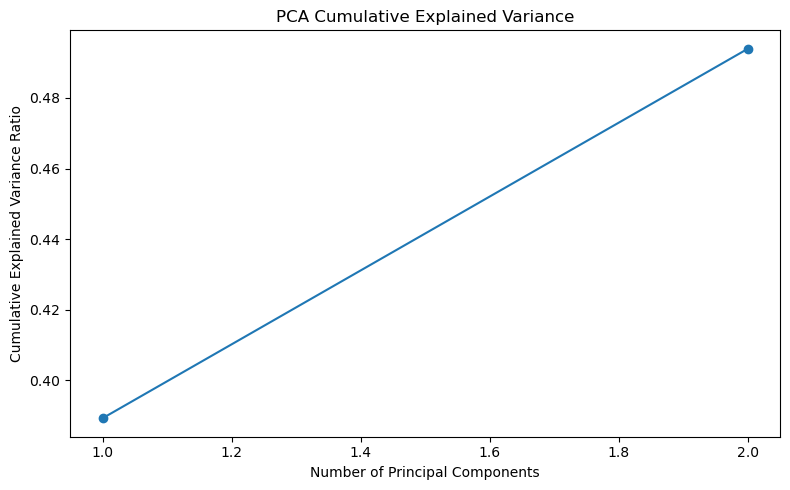

In [8]:
plot_pca_variance(pca)

In [9]:
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(10)

print("Top PC1 loadings:")
display(loadings.loc[top_pc1.index].sort_values("PC1", key=np.abs, ascending=False))

print("\nTop PC2 loadings:")
display(loadings.loc[top_pc2.index].sort_values("PC2", key=np.abs, ascending=False))

Top PC1 loadings:


,PC1,PC2
range_fie,0.163895,-0.027609
range_atomic_radius,0.163441,-0.021189
wtd_entropy_atomic_radius,0.163411,0.070706
wtd_std_fie,0.163281,-0.034387
wtd_std_atomic_radius,0.160298,-0.047224
entropy_Valence,0.158635,0.094144
wtd_entropy_atomic_mass,0.156476,0.085167
entropy_fie,0.156451,0.093663
wtd_entropy_Valence,0.155875,0.084410
wtd_gmean_Density,-0.155608,0.105904



Top PC2 loadings:


,PC1,PC2
gmean_atomic_radius,-0.078417,0.227941
mean_atomic_mass,-0.051328,0.224208
mean_atomic_radius,-0.020947,0.219775
gmean_atomic_mass,-0.082803,0.216152
wtd_mean_atomic_mass,-0.099202,0.200079
std_FusionHeat,-0.020759,-0.195727
wtd_std_FusionHeat,-0.010584,-0.188899
wtd_gmean_atomic_mass,-0.120003,0.184717
wtd_mean_atomic_radius,-0.119673,0.180074
range_FusionHeat,-0.003296,-0.176920


In the original notebook, density-related descriptors dominated the first two components. That is still physically plausible. It suggests that broad density statistics and density variability capture a large share of compositional variation across the dataset.

This does **not** mean density alone explains superconductivity. It means density-related statistics are major axes of variation in the feature space. PCA reveals structure in the predictors, not causal structure in the target.

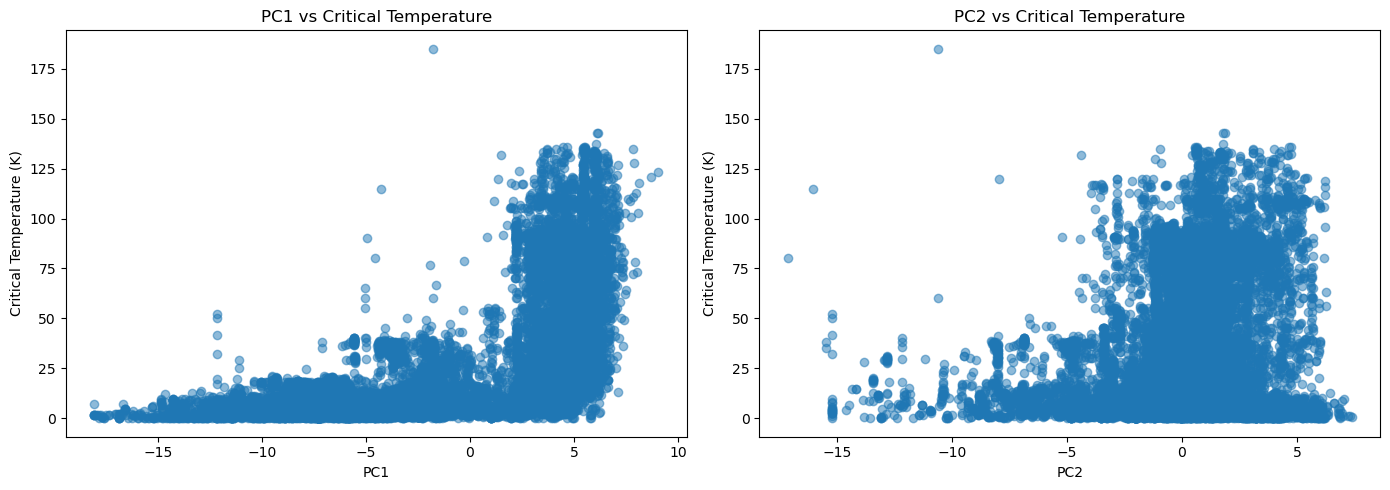

In [10]:
plot_pc_vs_target(X_train_pca, y_train)

## Unsupervised Learning with K-Means

K-Means is used to test whether the materials fall into broad clusters in standardized feature space. If higher-Tc compounds tend to occupy a narrower region, that can motivate more targeted modeling strategies later.

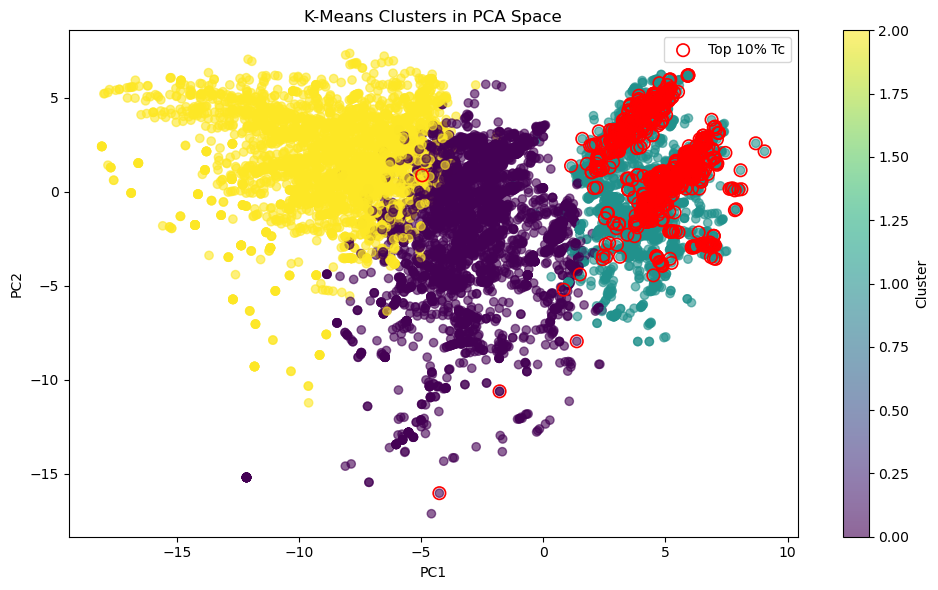

In [11]:
kmeans, train_clusters = fit_kmeans(X_train_scaled, k=3)
plot_clusters(X_train_pca, train_clusters, y_train, high_tc_quantile=0.9)

### Interpretation

If higher-Tc materials appear concentrated in one cluster or region of PCA space, that suggests the dataset contains non-random compositional structure associated with critical temperature. This is useful even before supervised prediction, because it implies that unsupervised learning can help identify promising subspaces of materials for screening.

At the same time, clustering should not be over-interpreted. K-Means imposes spherical partitions and depends on the chosen number of clusters. It is best viewed here as a coarse structural probe.

## Supervised Learning with Random Forest Regression

Random Forest regression is appropriate here because:

- the dataset is tabular and fully numerical
- feature interactions are likely nonlinear
- tree ensembles can model complex relationships without strong distributional assumptions
- the method provides straightforward feature importance estimates

Unlike PCA and K-Means, the Random Forest is trained on the original feature space. Tree models do not require feature scaling.

In [12]:
model, y_pred, test_metrics = fit_evaluate_random_forest(X_train, X_test, y_train, y_test)
display_metrics(test_metrics, title="test_set")

,value
r2,0.930059
rmse,8.972641
mae,5.079532


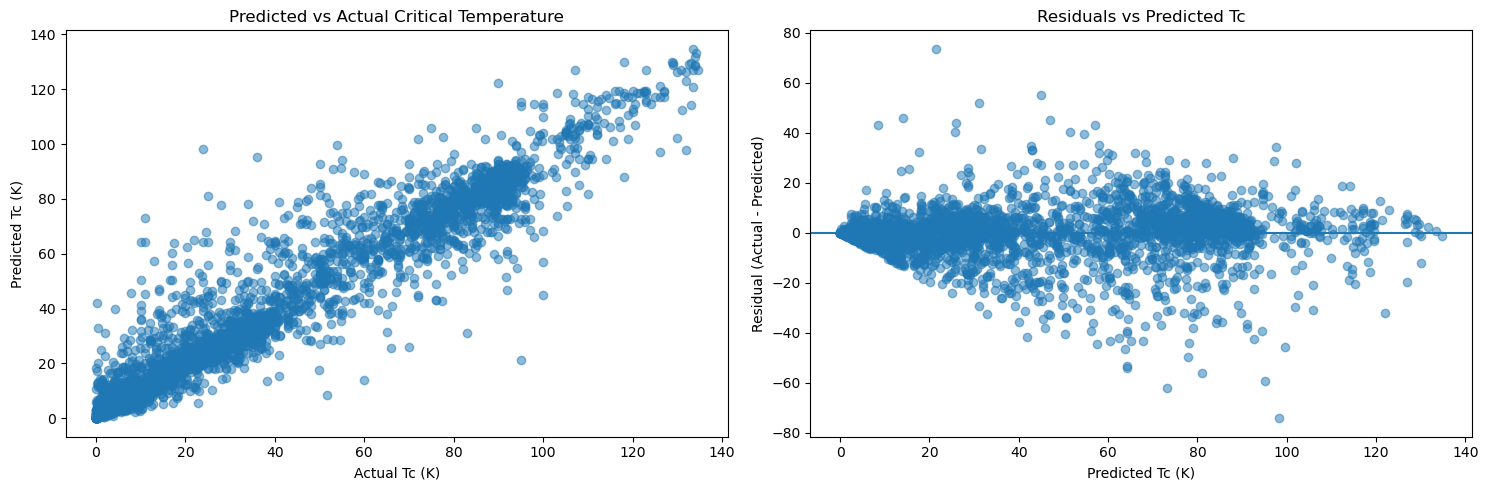

In [13]:
plot_predictions(y_test, y_pred)

### Model Evaluation

A strong R² together with relatively low RMSE and MAE indicates that composition-derived descriptors carry substantial predictive information about critical temperature.

The predicted-versus-actual plot should be read carefully. Good overall agreement can still mask local weaknesses, especially in sparsely populated target ranges. The residual plot helps check whether the model is systematically underpredicting or overpredicting in specific regions.

## Cross-Validation

Next, we will attempt to demonstrate model performance across folds.

In [14]:
X_full, y_full = split_features_target(data, target_col="critical_temp")
cv_results = cross_validate_random_forest(X_full, y_full, cv=5)
display_metrics(
    {k: v for k, v in cv_results.items() if k != "cv_r2_scores"},
    title="cross_validation",
)

,value
cv_r2_mean,0.925909
cv_r2_std,0.002858


In [15]:
pd.DataFrame({"fold": range(1, 6), "r2_score": cv_results["cv_r2_scores"]})

,fold,r2_score
0,1,0.930356
1,2,0.921734
2,3,0.924330
3,4,0.926179
4,5,0.926943


## Feature Importance

Feature importance helps identify which descriptors the Random Forest relies on most heavily. This is not the same as causal importance, but it does provide a useful ranking of predictive relevance within the trained model.

In [16]:
top_features = feature_importance_table(model, X_train.columns, top_n=15)
top_features

,feature,importance
67,range_ThermalConductivity,0.536183
64,wtd_gmean_ThermalConductivity,0.125953
9,std_atomic_mass,0.022186
74,wtd_gmean_Valence,0.018685
39,std_Density,0.011488
31,mean_Density,0.010973
66,wtd_entropy_ThermalConductivity,0.010826
43,gmean_ElectronAffinity,0.010594
72,wtd_mean_Valence,0.010417
70,wtd_std_ThermalConductivity,0.009828


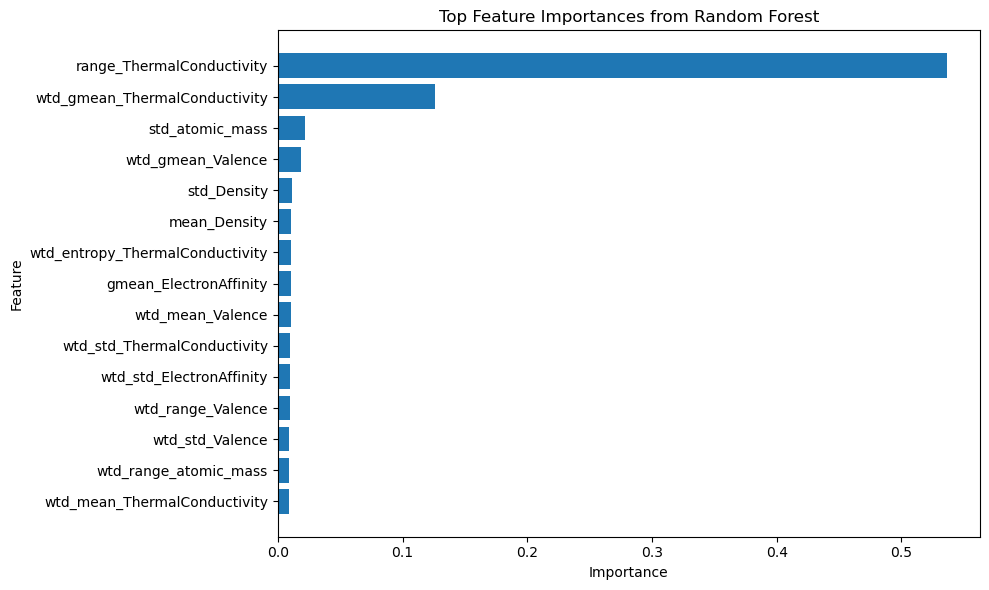

In [17]:
plot_feature_importance(top_features)

### Interpretation of Feature Importance

In the original notebook, **thermal conductivity variation** appeared especially important, with additional contributions from atomic-mass and weighted property statistics. That is a credible and interesting result for a portfolio narrative because it shows the model is not simply memorizing arbitrary columns. It is relying on physically interpretable composition-derived descriptors.

Still, feature importance in Random Forests has limitations:
- correlated features can split importance across several related columns
- importance reflects usefulness for this specific model, not mechanism
- composition-only descriptors cannot fully encode crystal structure or electronic band effects

That means the analysis is best framed as **predictive materials screening**, not as a complete physical theory of superconductivity.

## Key Findings

1. **The dataset contains meaningful structure**  
   PCA and K-Means suggest that superconducting materials occupy non-random regions of feature space.

2. **Composition-based descriptors are strongly predictive**  
   Random Forest regression can explain a large fraction of variance in critical temperature.

3. **Certain physical descriptors stand out**  
   Density- and thermal-conductivity-related statistics appear prominently in both unsupervised and supervised analysis.

4. **The workflow is useful, but limited**  
   Composition-based ML can support materials discovery, but it does not replace theory or structure-aware modeling.

## Limitations

This project is stronger than the original class notebook, but several limitations remain:

- the features are composition-derived and do not explicitly encode crystal structure
- the target distribution may be imbalanced across Tc regimes
- K-Means is a simplified clustering method
- Random Forest feature importance is useful but not fully explanatory
- strong predictive performance does not imply physical causation

## Conclusion

This project demonstrates a complete machine learning workflow for scientific tabular data with a materials-science application. The main portfolio value comes from three things:

- a clear scientific question
- a technically sound ML pipeline
- interpretation that stays honest about what the model can and cannot claim

Framed this way, the project is no longer just a class exercise. It becomes a credible example of **materials informatics**, **scientific machine learning**, and **data-driven analysis for physics-oriented problems**.